In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [260]:
df=pd.read_csv('./Data_Set/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [261]:
df.shape

(10000, 14)

In [262]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [264]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [265]:
df.shape

(10000, 11)

In [266]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [267]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [268]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [269]:
df.head()
df.tail()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True
9999,792,28,4,130142.79,1,1,0,38190.78,0,False,False,False


In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.5 KB


In [271]:
X=df.drop(columns=['Exited'])
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [272]:
len(X)

10000

In [273]:
y=df['Exited']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [274]:
len(y)

10000

In [275]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [276]:
X_train.shape

(8000, 11)

In [277]:
X_test.shape

(2000, 11)

In [278]:
y_train.shape

(8000,)

In [279]:
y_test.shape

(2000,)

In [280]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [281]:
X_train_scaled=scaler.fit_transform(X_train)

In [282]:
X_train_scaled.shape

(8000, 11)

In [283]:
X_test_scaled=scaler.fit_transform(X_test)

In [284]:
X_test_scaled.shape

(2000, 11)

In [285]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [286]:
model=Sequential()

In [287]:
model.add(Dense(4,activation='relu',input_dim=11))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\R.C\.conda\envs\Deep_Learning\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [288]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

Compile the model

model.compile(loss_function,optimizer for gradient_decient,metrics_accuracy)

In [291]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [310]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.3450 - val_accuracy: 0.8662 - val_loss: 0.3404
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - loss: 0.3553 - val_accuracy: 0.8644 - val_loss: 0.3413
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8576 - loss: 0.3485 - val_accuracy: 0.8637 - val_loss: 0.3420
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8597 - loss: 0.3365 - val_accuracy: 0.8669 - val_loss: 0.3408
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8629 - loss: 0.3346 - val_accuracy: 0.8644 - val_loss: 0.3413
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8598 - loss: 0.3386 - val_accuracy: 0.8681 - val_loss: 0.3402
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8619 - loss: 0.3334 - val_accuracy: 0.8669 - val_loss: 0.3409
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8472 - loss: 0.3662 - val_accuracy: 0.8644

In [296]:
model.layers[2].get_weights()

[array([[1.2540373],
        [0.8474614],
        [1.3243233]], dtype=float32),
 array([-2.3215482], dtype=float32)]

In [297]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [298]:
y_log

array([[0.089354  ],
       [0.089354  ],
       [0.31909776],
       ...,
       [0.089354  ],
       [0.11691663],
       [0.59027654]], dtype=float32)

Due to sigmoid 

In [299]:
y_predict=np.where(y_log>0.5,1,0)

In [300]:
y_predict

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]])

In [301]:
from sklearn.metrics import accuracy_score

In [302]:
accuracy_score(y_test,y_predict)

0.8585

In [304]:
history

In [305]:
history.history

{'accuracy': [0.8534374833106995,
  0.8532812595367432,
  0.8545312285423279,
  0.8550000190734863,
  0.8553125262260437,
  0.8539062738418579,
  0.8537499904632568,
  0.8548437356948853,
  0.8564062714576721,
  0.8550000190734863,
  0.8553125262260437,
  0.8556249737739563,
  0.8559374809265137,
  0.8570312261581421,
  0.8573437333106995,
  0.8565624952316284,
  0.8559374809265137,
  0.8573437333106995,
  0.856249988079071,
  0.8571875095367432],
 'loss': [0.3634590208530426,
  0.3617910146713257,
  0.3602747619152069,
  0.3587287664413452,
  0.3577471077442169,
  0.3568275570869446,
  0.3558032512664795,
  0.35486239194869995,
  0.3539629876613617,
  0.3539281189441681,
  0.35294774174690247,
  0.35212111473083496,
  0.35149550437927246,
  0.35114654898643494,
  0.35066014528274536,
  0.3502848446369171,
  0.3498353660106659,
  0.349557489156723,
  0.3492303490638733,
  0.3488457500934601],
 'val_accuracy': [0.8643749952316284,
  0.8643749952316284,
  0.8643749952316284,
  0.86187499

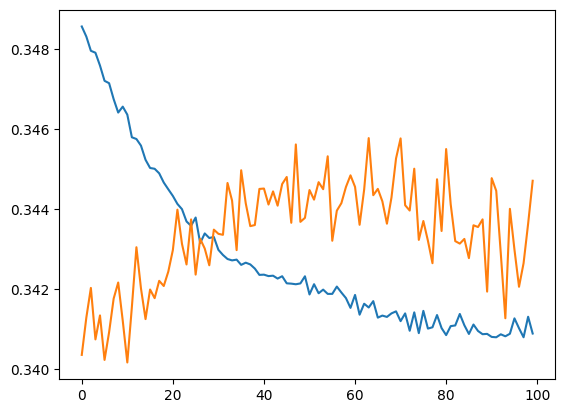

In [311]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

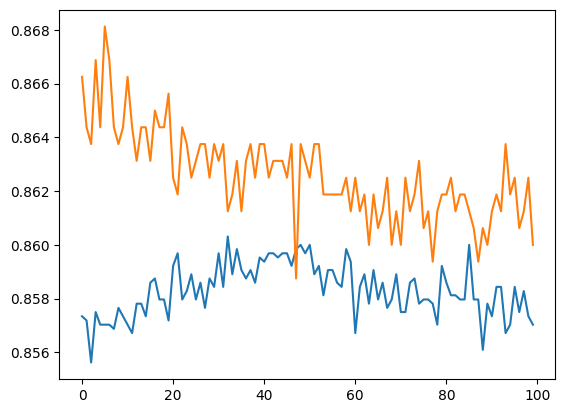

In [312]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])